In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from numpy.linalg import eig
import pandas as pd

In [2]:
path = f'D:/ML_Diffusion/dual_cat/c2c6_74h2o/'
rep=0
natoms=850
nsheet=574
cat1='C2'
ncat1=19
cat2='C6'
ncat2=31
n1_indx=nsheet
n2_indx=nsheet+ncat1
nsteps=5001
bx=30.396
by= 13.392
bz=15

In [3]:
def oh_dat(nsteps, oh_id_file):
    indx=np.zeros(nsteps)
    ox=np.zeros(nsteps)
    oy=np.zeros(nsteps)
    oz=np.zeros(nsteps)
    with open(path + oh_id_file, 'r') as oh:
        xyz= oh.readlines()
        for i in range(nsteps):
            indx[i]=int(xyz[i].split()[1])
            ox[i]=float(xyz[i].split()[2])
            oy[i]=float(xyz[i].split()[3])
            oz[i]=float(xyz[i].split()[4])
    return(indx, ox, oy, oz)
      

In [4]:
def move_to_box(x, y, z, bx, by, bz):
    # insert x, y, z coordinates as 1D arrays and move atoms into the box
    if (x)>bx/2:
        dx= int((abs(x)-bx/2)/bx)+1
        x_new=float(x-(dx*bx))
    if (x)<-bx/2:
        dx= int((abs(x)-bx/2)/bx)+1
        x_new=float(x+ (dx*bx))
    if -bx/2<=x<=bx/2:
        x_new=x
    if (y)>by/2:
        dy= int((abs(y)-by/2)/by)+1
        y_new=float(y- (dy*by))
    if (y)<-by/2:
        dy= int((abs(y)-by/2)/by)+1
        y_new=float(y+ (dy*by))
    if -by/2<=y<=by/2:
        y_new=y
        
    if (z)>bz/2:
        dz= int((abs(z)-bz/2)/bz)+1
        z_new=float(z- (dz*bz))
    if (z)<-bz/2:
        dz= int((abs(z)-bz/2)/bz)+1
        z_new=float(z (dz*bz))
    if -bz/2<=z<=bz/2:
        z_new=z
    return(x_new, y_new, z_new)
        

In [5]:
indx1, o1x, o1y, o1z = oh_dat(nsteps, f'oh1.{rep}_id.dat' )
indx2, o2x, o2y, o2z= oh_dat(nsteps, f'oh2.{rep}_id.dat' )

In [6]:
dist_no = pd.DataFrame(columns=['nstep', 
                                'rx_o1n1', 'ry_o1n1', 'rz_o1n1', 'r_o1n1',
                                'rx_o2n2', 'ry_o2n2', 'rz_o2n2', 'r_o2n2',
                                'rx_o2n1', 'ry_o2n1', 'rz_o2n1', 'r_o2n1',
                                'rx_o1n2', 'ry_o1n2', 'rz_o1n2', 'r_o1n2',])

with open(path +'geo_end.xyz', 'r') as out_file:
    xyz= out_file.readlines()
    for i in range(nsteps):
        end = (i+1)*(natoms+2)
        start= end - natoms
        o1_indx=int(indx1[i])
        o2_indx=int(indx2[i])

        o1_x= o1x[i]
        o1_y= o1y[i]
        o1_z= o1z[i]   

        o2_x= o2x[i]
        o2_y= o2y[i]
        o2_z= o2z[i]
        
        n1_x= float(xyz[start+n1_indx].split()[1])
        n1_y= float(xyz[start+n1_indx].split()[2])
        n1_z= float(xyz[start+n1_indx].split()[3])
        n1_x, n1_y, n1_z= move_to_box(n1_x, n1_y, n1_z, bx, by, bz)

        n2_x= float(xyz[start+n2_indx].split()[1])
        n2_y= float(xyz[start+n2_indx].split()[2])
        n2_z= float(xyz[start+n2_indx].split()[3])
        n2_x, n2_y, n2_z= move_to_box(n2_x, n2_y, n2_z, bx, by, bz)

        dist_no.loc[i,"nstep"]=i
        
        #dist_n1_o1
        dist_no.loc[i,"rx_o1n1"]= abs(o1_x-n1_x)
        dist_no.loc[i,"ry_o1n1"]= abs(o1_y-n1_y)
        dist_no.loc[i,"rz_o1n1"]= abs(o1_z-n1_z)
        dist_no.loc[i,"r_o1n1"]= np.sqrt((o1_x-n1_x)**2 + (o1_y-n1_y)**2 + (o1_z-n1_z)**2)

        #dist_n2_o2
        dist_no.loc[i,"rx_o2n2"]= abs(o2_x-n2_x)
        dist_no.loc[i,"ry_o2n2"]= abs(o2_y-n2_y)
        dist_no.loc[i,"rz_o2n2"]= abs(o2_z-n2_z)
        dist_no.loc[i,"r_o2n2"]= np.sqrt((o2_x-n2_x)**2 + (o2_y-n2_y)**2 + (o2_z-n2_z)**2) 

        #dist_n1_o2
        dist_no.loc[i,"rx_o2n1"]= abs(o2_x-n1_x)
        dist_no.loc[i,"ry_o2n1"]= abs(o2_y-n1_y)
        dist_no.loc[i,"rz_o2n1"]= abs(o2_z-n1_z)
        dist_no.loc[i,"r_o2n1"]= np.sqrt((o2_x-n1_x)**2 + (o2_y-n1_y)**2 + (o2_z-n1_z)**2)

        #dist_n2_o1
        dist_no.loc[i,"rx_o1n2"]= abs(o1_x-n2_x)
        dist_no.loc[i,"ry_o1n2"]= abs(o1_y-n2_y)
        dist_no.loc[i,"rz_o1n2"]= abs(o1_z-n2_z)
        dist_no.loc[i,"r_o1n2"]= np.sqrt((o1_x-n2_x)**2 + (o1_y-n2_y)**2 + (o1_z-n2_z)**2)        


dist_no.to_csv(path+f"dist_no_{rep}.csv", index=False)
        

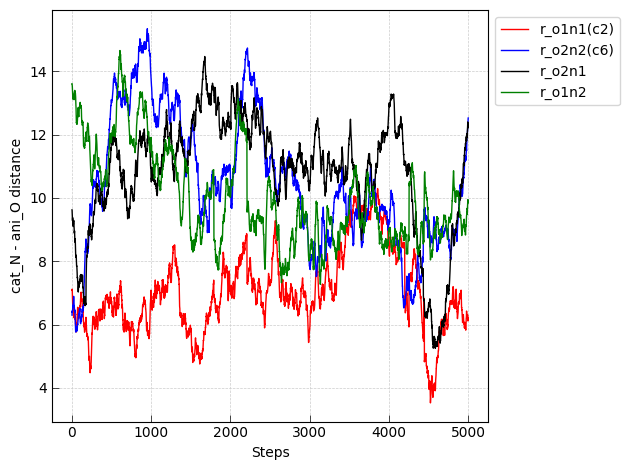

In [7]:
plt.figure()
plt.plot(dist_no["nstep"], dist_no["r_o1n1"],color='red',linewidth=1,label="r_o1n1(c2)")
plt.plot(dist_no["nstep"], dist_no["r_o2n2"],color='blue',linewidth=1,label="r_o2n2(c6)")
plt.plot(dist_no["nstep"], dist_no["r_o2n1"],color='black',linewidth=1,label="r_o2n1")
plt.plot(dist_no["nstep"], dist_no["r_o1n2"],color='green',linewidth=1,label="r_o1n2")
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel('Steps')
plt.ylabel('cat_N - ani_O distance')
#plt.title("Distance between N of Cations and O of anions")
plt.tick_params(axis="x",which='major', direction="in", length=5, width=0.5)
plt.tick_params(axis="y",which='major',direction="in", length=5, width=0.5)
plt.tick_params(axis="x",which='minor', direction="in", length=5, width=0.5)
plt.tick_params(axis="y",which='minor',direction="in", length=5, width=0.5)
plt.grid(which='major',color='#CCCCCC', linestyle='--', linewidth=0.5)
#plt.ticklabel_format(axis="x", style="plain", scilimits=(0,0),useMathText=True)
#plt.ylim([0,80])
#plt.tick_params(bottom=True, top=True, left=True, right=True)
plt.tight_layout() 
plt.savefig(path +f'dist_cat_oh_{rep}.jpg', dpi=100) 

In [8]:
#O2_id  4285  688        15.20117296     -9.57756044     -1.29716162
 #gen_geo            O   15.20117296      3.81443956     -1.29716162
 #gen_geo moved         -15.19482704      3.81443956     -1.29716162
#	rx_o2n2	ry_o2n2	rz_o2n2	r_o2n2
#4285	5.7389161999999985	4.56117029	0.50540239	7.348119837129687                  
o2_x=   15.20117296   
o2_y=  -9.57756044    
o2_z= -1.29716162  
#N   
n2_x=   9.39535285   
n2_y= -0.71441072   
n2_z=-0.71961775

np.sqrt((o2_x-n2_x)**2 + (o2_y-n2_y)**2 + (o2_z-n2_z)**2) 

np.float64(10.611151070010786)

In [16]:
o2_z-n2_z


-0.5775438700000001

In [10]:
# 4285  775        -2.85633972      4.90355640      0.78960029
#O   
o1x=-2.85633972   
o1y=4.90355640   
o1z=0.78960029
#N   
n1x=-3.51796213   
n1y=-0.46900178   
n1z=3.09958023
np.sqrt((o1x-n1x)**2 + (o1y-n1y)**2 + (o1z-n1z)**2) 

np.float64(5.885416971982659)

In [11]:
move_to_box(15.20117296,3.81443956,-1.29716162,bx,by,bz)

(-15.194827040000002, 3.81443956, -1.29716162)

In [12]:
          
       
np.sqrt(( 15.20117296 -9.39535285)**2 + (-9.57756044--0.71441072)**2 + (-1.29716162--0.71961775)**2) 

np.float64(10.611151070010786)

In [13]:
	nstep	rx_o1n1	ry_o1n1	rz_o1n1	r_o1n1	rx_o2n2	ry_o2n2
4285	4284	0.7454441700000003	5.39257748	2.22727136	5.881863361169349	5.7389161999999985	4.56117029


IndentationError: unexpected indent (2911941985.py, line 1)